# CryptoSage — Model Training, Risk Engine & Recommendation Engine
## Full Evaluation & Publication-Figure Notebook

This notebook is a **single source of truth** for:

1. Exploring the CryptoSage dataset (`dataset/data/processed/{train,test}.csv`)
2. Running the Phase 6 hierarchical training pipeline (`ml/train.py`) end-to-end
3. Displaying every evaluation metric the pipeline produces (accuracy, balanced
   accuracy, precision/recall/F1 macro, ROC-AUC, confusion matrices, SHAP)
4. Exercising the deterministic **Risk Engine** (`ml/risk.py`) on real predictions
   and validating its arithmetic
5. Exercising the deterministic **Recommendation Engine** (`ml/recommend.py`) and
   checking rule coverage
6. Producing **publication-quality figures** (300 DPI, IEEE column sizing) saved to
   `paper_figures/` for direct inclusion in a manuscript

**Design principle: nothing here is fabricated.** Every number and every figure is
computed from your actual dataset and your actual trained model. If a required file
(dataset, trained model, config) is missing, the corresponding cell tells you exactly
what's missing and stops — it never substitutes placeholder numbers into a metric or
a plot. The one section that intentionally uses an editable, synthetic feature vector
(to demo the risk engine's arithmetic in isolation) is clearly labelled
**"SYNTHETIC / ILLUSTRATIVE"** so it's never confused with a reported result.

> **Before running:** place this notebook anywhere *inside* your project checkout
> (e.g. `backend/ml/notebooks/analysis.ipynb`). The bootstrap cell walks up the
> directory tree looking for a folder containing both `ml/` and `dataset/`
> subfolders and adds it to `sys.path`. If your layout differs, edit `BACKEND_DIR`
> directly in that cell.

## 0. Environment, Path Bootstrap & Reproducibility

For a methods section you need to be able to state *exactly* what produced these
numbers: package versions, random seed, dataset identity. This section records all
three.

In [2]:
import sys, os, json, platform, hashlib, warnings, importlib
from pathlib import Path

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

def find_project_root(start: Path, markers=("ml", "dataset")) -> Path:
    # Walk upward from `start` until a directory containing every folder in
    # `markers` is found. Returns `start` unchanged (with a printed warning) if
    # nothing is found within 8 levels.
    current = start.resolve()
    for _ in range(8):
        if all((current / m).is_dir() for m in markers):
            return current
        if current.parent == current:
            break
        current = current.parent
    print(
        f"WARNING: could not locate a directory containing {markers} within 8 "
        f"levels above {start}. Set BACKEND_DIR manually below if imports fail, "
        f"e.g.: BACKEND_DIR = Path('/absolute/path/to/backend')"
    )
    return start.resolve()

NOTEBOOK_DIR = Path.cwd()
BACKEND_DIR = find_project_root(NOTEBOOK_DIR)

if str(BACKEND_DIR) not in sys.path:
    sys.path.insert(0, str(BACKEND_DIR))

print(f"Notebook directory : {NOTEBOOK_DIR}")
print(f"Project (backend)  : {BACKEND_DIR}")
print(f"sys.path[0]         = {sys.path[0]}")

Notebook directory : /home/manya_11/CryptoSage/backend
Project (backend)  : /home/manya_11/CryptoSage/backend
sys.path[0]         = /home/manya_11/CryptoSage/backend


In [3]:
'//wsl.localhost/Ubuntu-26.04/home/manya_11/CryptoSage/.venv/Scripts/python.exe -m pip install ipykernel -U --force-reinstall'

'//wsl.localhost/Ubuntu-26.04/home/manya_11/CryptoSage/.venv/Scripts/python.exe -m pip install ipykernel -U --force-reinstall'

In [4]:
# --- Package versions: paste this table into your paper's reproducibility appendix ---
import pandas as pd

_pkgs = ["numpy", "pandas", "sklearn", "matplotlib", "seaborn", "shap", "joblib", "xgboost"]
_rows = []
for _pkg in _pkgs:
    try:
        _mod = importlib.import_module(_pkg)
        _rows.append((_pkg, getattr(_mod, "__version__", "unknown"), True))
    except ImportError:
        _rows.append((_pkg, "NOT INSTALLED", False))

version_table = pd.DataFrame(_rows, columns=["package", "version", "installed"])
print(f"Python   : {platform.python_version()}")
print(f"Platform : {platform.platform()}")
version_table

Python   : 3.12.11
Platform : Linux-6.6.114.1-microsoft-standard-WSL2-x86_64-with-glibc2.43


,package,version,installed
0,numpy,2.4.4,True
1,pandas,3.0.2,True
2,sklearn,1.9.0,True
3,matplotlib,3.10.8,True
4,seaborn,0.13.2,True
5,shap,0.52.0,True
6,joblib,1.5.3,True
7,xgboost,3.4.0,True


In [5]:
import numpy as np

RANDOM_STATE = 42  # must match ml/train.py's RANDOM_STATE for numbers to reproduce
np.random.seed(RANDOM_STATE)
print(f"Global random seed fixed to {RANDOM_STATE} (matches ml/train.py RANDOM_STATE).")

Global random seed fixed to 42 (matches ml/train.py RANDOM_STATE).


## 0b. Publication Plot Style

IEEE double-column papers typically render a full-width figure at **~7.16 in** and a
single-column figure at **~3.5 in**. We fix a consistent style once (serif font,
300 DPI, sensible sizes) and reuse two width constants throughout. `savefig_paper()`
writes both a PNG (quick preview) and a PDF (vector, for `\includegraphics`) into
`paper_figures/`, and records a caption stub for the index printed at the end of the
notebook.

In [6]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

IEEE_COL_WIDTH_IN = 3.5      # single-column figure width
IEEE_PAGE_WIDTH_IN = 7.16    # double-column (full width) figure width

mpl.rcParams.update({
    "figure.dpi": 150,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.size": 9,
    "axes.titlesize": 10,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "savefig.bbox": "tight",
})
sns.set_palette("colorblind")

FIGURES_DIR = NOTEBOOK_DIR / "paper_figures"
FIGURES_DIR.mkdir(exist_ok=True)

_saved_figures = []  # (filename, caption) -> printed as an index at the end

def savefig_paper(fig, name: str, caption: str = ""):
    # Save a figure as both a 300dpi PNG and a vector PDF under paper_figures/.
    png_path = FIGURES_DIR / f"{name}.png"
    pdf_path = FIGURES_DIR / f"{name}.pdf"
    fig.savefig(png_path)
    fig.savefig(pdf_path)
    _saved_figures.append((name, caption))
    print(f"Saved: {png_path.name}, {pdf_path.name}")

print(f"Figures will be written to: {FIGURES_DIR}")

Figures will be written to: /home/manya_11/CryptoSage/backend/paper_figures


## 1. Load the Dataset

Uses `ml.train.load_dataset()` directly — the exact same loader the training
pipeline uses — so what you inspect here is guaranteed to be what gets trained on,
not a re-implementation that could silently drift from it.

In [7]:
from ml.train import (
    load_dataset, TRAIN_CSV_PATH, TEST_CSV_PATH, TARGET_COLUMN,
    resolve_candidate_feature_columns, select_features,
    prepare_labels, LEAKAGE_BASE_COLUMNS,
)
from analysis.constants import ALGORITHM_FAMILIES, KNOWN_FAMILIES

print(f"TRAIN_CSV_PATH = {TRAIN_CSV_PATH}  (exists: {TRAIN_CSV_PATH.exists()})")
print(f"TEST_CSV_PATH  = {TEST_CSV_PATH}  (exists: {TEST_CSV_PATH.exists()})")

if not TRAIN_CSV_PATH.exists() or not TEST_CSV_PATH.exists():
    raise FileNotFoundError(
        "train.csv / test.csv not found. Run the Dataset Builder first:\n"
        "  python dataset/builder.py && python dataset/preprocess.py\n"
        "from the backend/ directory, then re-run this cell."
    )

train_df, test_df = load_dataset(TRAIN_CSV_PATH, TEST_CSV_PATH)

# Dataset fingerprint — record this in your paper so results are traceable to an
# exact data snapshot.
def _file_sha256(path: Path) -> str:
    h = hashlib.sha256()
    h.update(path.read_bytes())
    return h.hexdigest()[:16]

print(f"train.csv sha256 (16 hex): {_file_sha256(TRAIN_CSV_PATH)}")
print(f"test.csv  sha256 (16 hex): {_file_sha256(TEST_CSV_PATH)}")
print(f"\ntrain_df shape: {train_df.shape}")
print(f"test_df  shape: {test_df.shape}")

TRAIN_CSV_PATH = /home/manya_11/CryptoSage/backend/dataset/data/processed/train.csv  (exists: True)
TEST_CSV_PATH  = /home/manya_11/CryptoSage/backend/dataset/data/processed/test.csv  (exists: True)
train.csv sha256 (16 hex): c42b3b2a7597f5ae
test.csv  sha256 (16 hex): d716b60ff411100f

train_df shape: (5666, 142)
test_df  shape: (1429, 142)


In [8]:
train_df.head(10)

,binary_name,project,algorithm_label,architecture,optimization_level,compiler,compiler_version,build_type,build_system,binary_type,...,segment_count_normalized,sha1_constant_count_normalized,sha224_constant_count_normalized,sha256_constant_count_normalized,sha384_constant_count_normalized,sha512_constant_count_normalized,string_count_normalized,symbol_count_normalized,unique_opcode_ratio_normalized,writable_section_ratio_normalized
0,armv8-32-sha256-asm_c__clang_O1_debug.o,wolfssl,SHA256,x86_64,O1,clang,clang (cached build),debug,direct_compile,object,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.093711,0.0
1,rsa_sign_saltlen_get__clang_O0_debug.o,libtomcrypt,RSA,x86_64,O0,clang,clang (cached build),debug,direct_compile,object,...,0.0,0.0,0.0,0.0,0.0,0.0,0.031066,0.032864,0.357429,0.0
2,thumb2-sha3-asm_c__gcc_O2_release.o,wolfssl,SHA3,x86_64,O2,gcc,gcc (cached build),release,direct_compile,object,...,0.0,0.0,0.0,0.0,0.0,0.0,0.001180,0.000000,0.093711,0.0
3,rsa_x931g__gcc_O3_debug.o,openssl,RSA,x86_64,O3,gcc,gcc (cached build),debug,direct_compile,object,...,0.0,0.0,0.0,0.0,0.0,0.0,0.066850,0.089202,0.040186,0.0
4,devcrypto_rsa__clang_O2_release.o,wolfssl,RSA,x86_64,O2,clang,clang (cached build),release,direct_compile,object,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.093711,0.0
5,ppc32-sha256-asm_cr__gcc_O2_debug.o,wolfssl,SHA256,x86_64,O2,gcc,gcc (cached build),debug,direct_compile,object,...,0.0,0.0,0.0,0.0,0.0,0.0,0.010617,0.000000,0.093711,0.0
6,salsa20_xmm6int-neon__clang_O1_release.o,libsodium,ChaCha20,x86_64,O1,clang,clang (cached build),release,direct_compile,object,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.093711,0.0
7,ecc_rfc6979_key__gcc_O2_release.o,libtomcrypt,ECC,x86_64,O2,gcc,gcc (cached build),release,direct_compile,object,...,0.0,0.0,0.0,0.0,0.0,0.0,0.025560,0.093897,0.061313,0.0
8,thumb2-sha3-asm_c__clang_O0_debug.o,wolfssl,SHA3,x86_64,O0,clang,clang (cached build),debug,direct_compile,object,...,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.000000,0.093711,0.0
9,rsa_prn__gcc_O2_release.o,openssl,RSA,x86_64,O2,gcc,gcc (cached build),release,direct_compile,object,...,0.0,0.0,0.0,0.0,0.0,0.0,0.010617,0.070423,0.119378,0.0


In [9]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5666 entries, 0 to 5665
Columns: 142 entries, binary_name to writable_section_ratio_normalized
dtypes: bool(6), float64(64), int64(59), str(13)
memory usage: 5.9 MB


In [10]:
# Missing-value audit — worth reporting in the paper's data-quality subsection
missing_counts = train_df.isna().sum()
missing_pct = (missing_counts / len(train_df) * 100).round(2)
missing_summary = pd.DataFrame({"missing_count": missing_counts, "missing_pct": missing_pct})
missing_summary = missing_summary[missing_summary["missing_count"] > 0].sort_values("missing_pct", ascending=False)
if missing_summary.empty:
    print("No missing values found in train_df.")
else:
    display(missing_summary)

No missing values found in train_df.


In [11]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
aes_constant,5666.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
aes_constant_count,5666.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
aes_symbol,5666.0,0.113484,0.317211,0.0,0.000000,0.000000,0.000000,1.000000
arithmetic_count,5666.0,30.007413,128.793191,0.0,4.000000,8.000000,17.000000,3071.000000
basic_block_count_estimate,5666.0,73.445464,128.824145,1.0,20.000000,35.000000,56.000000,1236.000000
...,...,...,...,...,...,...,...,...
sha512_constant_count_normalized,5666.0,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000
string_count_normalized,5666.0,0.039042,0.057534,0.0,0.003539,0.015336,0.051121,0.761306
symbol_count_normalized,5666.0,0.084857,0.137301,0.0,0.000000,0.042254,0.089202,1.000000
unique_opcode_ratio_normalized,5666.0,0.147096,0.172177,0.0,0.058003,0.093711,0.139480,1.000000


## 2. Class Distribution (Algorithm & Family Level)

Class imbalance directly explains why the pipeline uses macro-averaged F1 and
`compute_sample_weight("balanced", ...)` rather than plain accuracy — this plot is
the evidence for that methodological choice and is a natural "Figure 1" for a
dataset-description section.

In [12]:
algo_counts_train = train_df[TARGET_COLUMN].astype(str).value_counts().sort_values(ascending=False)
algo_counts_test = test_df[TARGET_COLUMN].astype(str).value_counts()

family_series_train = train_df[TARGET_COLUMN].astype(str).map(ALGORITHM_FAMILIES)
family_counts_train = family_series_train.value_counts().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(IEEE_PAGE_WIDTH_IN, 3.2))

axes[0].barh(algo_counts_train.index[::-1], algo_counts_train.values[::-1], color=sns.color_palette("colorblind")[0])
axes[0].set_title("Algorithm class distribution (train)")
axes[0].set_xlabel("Sample count")

axes[1].barh(family_counts_train.index[::-1], family_counts_train.values[::-1], color=sns.color_palette("colorblind")[1])
axes[1].set_title("Family-level class distribution (train)")
axes[1].set_xlabel("Sample count")

fig.tight_layout()
savefig_paper(fig, "fig1_class_distribution", "Algorithm- and family-level class distribution in the training split.")
plt.show()

imbalance_ratio = algo_counts_train.max() / algo_counts_train.min()
print(f"Algorithm-level class imbalance ratio (max/min): {imbalance_ratio:.1f}x")
print(f"Number of algorithm classes: {train_df[TARGET_COLUMN].nunique()}")
print(f"Number of family classes:    {family_series_train.nunique()}")

Saved: fig1_class_distribution.png, fig1_class_distribution.pdf
Algorithm-level class imbalance ratio (max/min): 88.5x
Number of algorithm classes: 24
Number of family classes:    6


In [13]:
# Train vs. test class-proportion consistency check — a sanity check that the split
# didn't accidentally skew class balance, worth a one-line mention in the paper.
train_props = (algo_counts_train / algo_counts_train.sum()).rename("train_proportion")
test_props = (test_df[TARGET_COLUMN].astype(str).value_counts() / len(test_df)).rename("test_proportion")
split_check = pd.concat([train_props, test_props], axis=1).fillna(0).sort_values("train_proportion", ascending=False)
split_check["abs_diff"] = (split_check["train_proportion"] - split_check["test_proportion"]).abs()
display(split_check)
print(f"Max train/test proportion drift for any class: {split_check['abs_diff'].max():.4f}")

,train_proportion,test_proportion,abs_diff
algorithm_label,,,
ECC,0.187434,0.186144,0.001290
AES,0.169432,0.167950,0.001482
ChaCha20,0.148959,0.147656,0.001303
RSA,0.119661,0.118964,0.000697
SHA512,0.051888,0.051784,0.000104
X25519,0.045182,0.044787,0.000395
SHA256,0.038299,0.038488,0.000190
Poly1305,0.033886,0.033590,0.000296
HMAC,0.033886,0.033590,0.000296


Max train/test proportion drift for any class: 0.0015


## 3. Feature-Level Exploration

Uses the *same* metadata-leakage-aware candidate resolution as the training pipeline
(`resolve_candidate_feature_columns`), so the features you visualize here are
genuinely the ones the model can see — not project/compiler/build metadata, which
are excluded by design (see `LEAKAGE_BASE_COLUMNS`).

In [14]:
candidate_columns = resolve_candidate_feature_columns(train_df)
print(f"{len(candidate_columns)} candidate feature columns (post metadata-leakage removal).")
print(f"Excluded leakage columns: {sorted(LEAKAGE_BASE_COLUMNS)}")
candidate_columns[:30]

80 candidate feature columns (post metadata-leakage removal).
Excluded leakage columns: ['binary_name', 'binary_type', 'build_system', 'build_type', 'compiler', 'compiler_version', 'crypto_library', 'optimization_level', 'project']


['aes_constant',
 'aes_symbol',
 'chacha_symbol',
 'des_symbol',
 'ecc_curve_p_256',
 'ecc_curve_p_384',
 'ecc_curve_p_521',
 'ecc_curve_secp256k1',
 'ecc_symbol',
 'known_crypto_library',
 'md5_constant',
 'rsa_exponent_present',
 'rsa_symbol',
 'sha1_constant',
 'sha_constant',
 'sha_symbol',
 'arithmetic_count_was_missing',
 'basic_block_count_estimate_was_missing',
 'branch_count_was_missing',
 'call_count_was_missing',
 'call_graph_fanout_estimate_was_missing',
 'cfg_edge_count_estimate_was_missing',
 'cyclomatic_complexity_estimate_was_missing',
 'executable_section_ratio_was_missing',
 'import_libraries_was_missing',
 'instruction_count_was_missing',
 'instruction_entropy_was_missing',
 'jump_count_was_missing',
 'logical_count_was_missing',
 'memory_count_was_missing']

In [15]:
numeric_candidates = train_df[candidate_columns].apply(pd.to_numeric, errors="coerce")

# Pick a handful of the most human-interpretable features for distribution plots,
# falling back gracefully if a given column isn't present in this dataset build.
preferred = ["entropy", "binary_size_normalized", "symbol_count", "instruction_count",
             "executable_section_ratio", "unique_opcode_ratio"]
plot_features = [f for f in preferred if f in numeric_candidates.columns]
if len(plot_features) < 4:
    # top-up with whatever numeric candidates are available
    extra = [c for c in numeric_candidates.columns if c not in plot_features][: 6 - len(plot_features)]
    plot_features += extra

fig, axes = plt.subplots(2, 3, figsize=(IEEE_PAGE_WIDTH_IN, 4.2))
for ax, feature in zip(axes.flat, plot_features[:6]):
    sns.histplot(numeric_candidates[feature].dropna(), kde=True, ax=ax, color=sns.color_palette("colorblind")[2])
    ax.set_title(feature, fontsize=8)
    ax.set_xlabel("")
for ax in axes.flat[len(plot_features):]:
    ax.axis("off")
fig.suptitle("Distributions of representative features", y=1.02)
fig.tight_layout()
savefig_paper(fig, "fig2_feature_distributions", "Distributions of representative binary-content features.")
plt.show()

Saved: fig2_feature_distributions.png, fig2_feature_distributions.pdf


In [16]:
# Correlation heatmap over candidate features (pre feature-selection) —
# motivates the CORRELATION_THRESHOLD drop step in ml/train.py.
corr_sample_cols = candidate_columns if len(candidate_columns) <= 40 else candidate_columns[:40]
corr_matrix = numeric_candidates[corr_sample_cols].fillna(0).corr()

fig, ax = plt.subplots(figsize=(IEEE_PAGE_WIDTH_IN, IEEE_PAGE_WIDTH_IN * 0.85))
sns.heatmap(corr_matrix, cmap="coolwarm", center=0, square=True, ax=ax,
            cbar_kws={"shrink": 0.7}, xticklabels=True, yticklabels=True)
ax.set_title(f"Feature correlation matrix (first {len(corr_sample_cols)} candidates)")
ax.tick_params(axis="x", labelsize=5, rotation=90)
ax.tick_params(axis="y", labelsize=5)
fig.tight_layout()
savefig_paper(fig, "fig3_feature_correlation", "Pairwise Pearson correlation among candidate features before selection.")
plt.show()

Saved: fig3_feature_correlation.png, fig3_feature_correlation.pdf


In [17]:
# Feature separability check: 2D PCA projection colored by family.
# This is a good "does the feature space even separate the classes" sanity figure.
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_for_pca = numeric_candidates.fillna(0)
X_scaled = StandardScaler().fit_transform(X_for_pca)
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(IEEE_COL_WIDTH_IN, IEEE_COL_WIDTH_IN))
families_for_plot = family_series_train.values
palette = sns.color_palette("colorblind", n_colors=families_for_plot.nunique() if hasattr(families_for_plot, "nunique") else len(set(families_for_plot)))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=families_for_plot, palette=palette, s=12, alpha=0.7, ax=ax, legend="brief")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var.)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var.)")
ax.set_title("PCA projection of candidate features, colored by family")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=6, title_fontsize=7)
fig.tight_layout()
savefig_paper(fig, "fig4_pca_family_projection", "2D PCA projection of the candidate feature space, colored by algorithm family.")
plt.show()

print(f"Cumulative variance explained by PC1+PC2: {pca.explained_variance_ratio_.sum()*100:.1f}%")

Saved: fig4_pca_family_projection.png, fig4_pca_family_projection.pdf
Cumulative variance explained by PC1+PC2: 59.8%


## 4. Feature Selection

Calls `ml.train.select_features()` directly — constant-feature removal, then
correlation pruning (`|r| > 0.95`), then bottom-5th-percentile RandomForest
importance pruning — and persists the result to `feature_columns.json`, exactly as
`ml/train.py` does when run as a script. This is the feature set the model actually
trains on.

In [18]:
feature_columns = select_features(train_df, candidate_columns)
print(f"{len(candidate_columns)} candidates -> {len(feature_columns)} selected features.")
feature_columns

80 candidates -> 28 selected features.


['aes_symbol',
 'chacha_symbol',
 'des_symbol',
 'ecc_symbol',
 'md5_constant',
 'rsa_symbol',
 'sha_symbol',
 'arithmetic_count_was_missing',
 'arithmetic_count_normalized',
 'basic_block_count_estimate_normalized',
 'binary_size_normalized',
 'call_count_normalized',
 'call_graph_fanout_estimate_normalized',
 'entropy_normalized',
 'export_count_normalized',
 'function_count_normalized',
 'instruction_count_normalized',
 'instruction_entropy_normalized',
 'jump_count_normalized',
 'logical_count_normalized',
 'md5_constant_count_normalized',
 'opcode_bigram_entropy_normalized',
 'opcode_bigram_unique_ratio_normalized',
 'opcode_trigram_entropy_normalized',
 'return_count_normalized',
 'section_count_normalized',
 'string_count_normalized',
 'unique_opcode_ratio_normalized']

In [19]:
algorithm_encoder, family_encoder, all_algorithms, all_families = prepare_labels(train_df, test_df)

x_train = train_df[feature_columns].apply(pd.to_numeric, errors="coerce").fillna(0)
x_test = test_df[feature_columns].apply(pd.to_numeric, errors="coerce").fillna(0)

family_labels_train = family_encoder.transform(train_df[TARGET_COLUMN].astype(str).map(ALGORITHM_FAMILIES))

print(f"x_train: {x_train.shape}, x_test: {x_test.shape}")
print(f"Algorithm classes ({len(algorithm_encoder.classes_)}): {list(algorithm_encoder.classes_)}")
print(f"Family classes ({len(family_encoder.classes_)}): {list(family_encoder.classes_)}")

x_train: (5666, 28), x_test: (1429, 28)
Algorithm classes (24): ['3DES', 'AES', 'Argon2', 'Blowfish', 'Camellia', 'ChaCha20', 'DES', 'ECC', 'Ed25519', 'HKDF', 'HMAC', 'MD5', 'PBKDF2', 'Poly1305', 'RC4', 'RSA', 'SHA1', 'SHA224', 'SHA256', 'SHA3', 'SHA384', 'SHA512', 'Twofish', 'X25519']
Family classes (6): ['Hash Functions', 'Key Derivation', 'Message Authentication', 'Public Key Cryptography', 'Stream Cipher', 'Symmetric Encryption']


## 5. Train the Hierarchical Model

Two ways to run this, pick one:

- **Recommended for the paper's reported numbers:** call `ml.train.run_training()`
  directly — this is byte-for-byte the same function `python train.py` invokes, so
  the metrics you get here are identical to what a from-the-command-line run would
  produce, and it persists every artifact (`best_model.pkl`, `metrics.json`,
  `benchmark_results.json`, confusion-matrix PNGs, SHAP plots) to `ml/saved_models/`
  and `ml/reports/` for you.
- **For interactive exploration** (e.g. to inspect a single stage's benchmark table
  before committing to the full run), the cells further below re-run the individual
  stages (`train_family_stage`, `train_algorithm_submodels`,
  `evaluate_final_model`) using the `x_train`/`x_test` already prepared above.

⚠️ This performs a `RandomizedSearchCV` across 4 model families (RandomForest,
ExtraTrees, HistGradientBoosting, XGBoost if installed) with 5-fold CV — it can take
several minutes depending on dataset size and CPU core count.

In [20]:
RUN_FULL_TRAINING = True  # set False to skip re-training and only load a previously trained model in Section 6

if RUN_FULL_TRAINING:
    from ml.train import run_training
    training_result = run_training()
    print("\nTraining complete.")
    print(f"Winning model: {training_result['winning_model_key']}")
    print(f"Training duration: {training_result['training_duration_seconds']:.1f}s")
else:
    training_result = None
    print("Skipped full training (RUN_FULL_TRAINING = False). Section 6 will load saved_models/ artifacts instead.")


Training complete.
Winning model: extra_trees
Training duration: 194.3s


### 5a. Benchmark Table — Model Comparison (Stage 1: Family)

This is the evidence behind "we compared 4 model families and selected the best by
macro F1" — a natural table/figure for a methods or results section.

In [20]:
from ml.train import MODEL_REGISTRY, REPORTS_DIR as ML_REPORTS_DIR

benchmark_json_path = ML_REPORTS_DIR / "benchmark_results.json"
if not benchmark_json_path.exists():
    raise FileNotFoundError(
        f"{benchmark_json_path} not found — run Section 5's training cell first "
        "(RUN_FULL_TRAINING = True)."
    )

benchmark_results_raw = json.loads(benchmark_json_path.read_text())
winner_key = benchmark_results_raw.pop("winner")

benchmark_table = pd.DataFrame(benchmark_results_raw).T
benchmark_table = benchmark_table[["display_name", "cv_macro_f1", "cv_balanced_accuracy",
                                    "mean_inference_time_ms", "fit_duration_seconds"]]
benchmark_table = benchmark_table.sort_values("cv_macro_f1", ascending=False)
benchmark_table.columns = ["Model", "CV Macro F1", "CV Balanced Acc.", "Inference (ms/sample)", "Fit time (s)"]
print(f"Winning model: {MODEL_REGISTRY[winner_key].display_name} ({winner_key})")
benchmark_table

Winning model: ExtraTreesClassifier (extra_trees)


,Model,CV Macro F1,CV Balanced Acc.,Inference (ms/sample),Fit time (s)
extra_trees,ExtraTreesClassifier,0.968758,0.968683,0.738105,7.605794
random_forest,RandomForestClassifier,0.96372,0.96364,1.054197,20.509366
xgboost,XGBClassifier,0.947908,0.947492,0.313433,115.315986
hist_gradient_boosting,HistGradientBoostingClassifier,0.940976,0.940734,0.535708,117.131733


In [21]:
fig, axes = plt.subplots(1, 2, figsize=(IEEE_PAGE_WIDTH_IN, 3))

colors = [sns.color_palette("colorblind")[3] if idx == winner_key else sns.color_palette("colorblind")[7]
          for idx in benchmark_results_raw.keys()]

names = [benchmark_results_raw[k]["display_name"] for k in benchmark_results_raw]
f1_vals = [benchmark_results_raw[k]["cv_macro_f1"] for k in benchmark_results_raw]
inf_vals = [benchmark_results_raw[k]["mean_inference_time_ms"] for k in benchmark_results_raw]

axes[0].bar(names, f1_vals, color=colors)
axes[0].set_ylabel("CV macro F1")
axes[0].set_title("Cross-validated macro F1 by model")
axes[0].tick_params(axis="x", rotation=30)
axes[0].set_ylim(0, 1.0)

axes[1].bar(names, inf_vals, color=colors)
axes[1].set_ylabel("Mean inference time (ms/sample)")
axes[1].set_title("Inference latency by model")
axes[1].tick_params(axis="x", rotation=30)

fig.tight_layout()
savefig_paper(fig, "fig5_model_benchmark_comparison", "Cross-validated macro-F1 and inference latency across the four benchmarked model families; the selected model is highlighted.")
plt.show()

Saved: fig5_model_benchmark_comparison.png, fig5_model_benchmark_comparison.pdf


## 6. Load Trained Artifacts

Loads `best_model.pkl`, both label encoders, and `metadata.json` from
`ml/saved_models/` — either the ones you just produced in Section 5, or a
previously trained run if you set `RUN_FULL_TRAINING = False` above.

In [22]:
import joblib
from ml.train import SAVED_MODELS_DIR

model_bundle_path = SAVED_MODELS_DIR / "best_model.pkl"
if not model_bundle_path.exists():
    raise FileNotFoundError(
        f"{model_bundle_path} not found. Run Section 5 with RUN_FULL_TRAINING = True first."
    )

bundle = joblib.load(model_bundle_path)
family_model = bundle["family_model"]
algorithm_submodels = bundle["algorithm_submodels"]

loaded_family_encoder = joblib.load(SAVED_MODELS_DIR / "label_encoder.pkl")
loaded_algorithm_encoder = joblib.load(SAVED_MODELS_DIR / "algorithm_label_encoder.pkl")
model_metadata = json.loads((SAVED_MODELS_DIR / "metadata.json").read_text())

print(f"Loaded model: {model_metadata.get('winning_model')}")
print(f"Model version: {model_metadata.get('model_version')}")
print(f"Trained on: {model_metadata.get('training_date')}")
print(f"Feature count: {model_metadata.get('feature_count')}")
print(f"Training samples: {model_metadata.get('training_sample_count')}, "
      f"Test samples: {model_metadata.get('test_sample_count')}")
pd.Series(model_metadata).to_frame("value")

Loaded model: ExtraTreesClassifier
Model version: 2.0
Trained on: 2026-08-12T00:17:50.850622+00:00
Feature count: 28
Training samples: 5666, Test samples: 1429


,value
model_version,2.0
winning_model,ExtraTreesClassifier
dataset_version,1.0
training_date,2026-08-12T00:17:50.850622+00:00
macro_f1,0.933657
balanced_accuracy,0.938353
accuracy,0.952414
precision_macro,0.930824
recall_macro,0.938353
family_accuracy,0.982505


## 7. Final Held-Out Evaluation (`test.csv`, touched once)

Re-derives the same metrics `ml.train.evaluate_final_model()` computed and saved to
`ml/reports/metrics.json` during training — read directly from disk here so what you
see is exactly what got persisted, not a re-computation that could drift.

In [23]:
from ml.train import REPORTS_DIR as _RD

metrics_path = SAVED_MODELS_DIR / "metrics.json"
if not metrics_path.exists():
    raise FileNotFoundError(f"{metrics_path} not found — run Section 5 first.")

metrics = json.loads(metrics_path.read_text())

headline_metrics = {k: v for k, v in metrics.items()
                     if k not in ("algorithm_confusion_matrix", "family_confusion_matrix",
                                  "algorithm_class_names", "family_class_names", "shap_top_features")}
metrics_table = pd.Series(headline_metrics, name="value").to_frame()
metrics_table

,value
accuracy,0.952414
balanced_accuracy,0.938353
precision_macro,0.930824
recall_macro,0.938353
f1_macro,0.933657
family_accuracy,0.982505
family_f1_macro,0.980786
family_roc_auc_macro,0.999526


In [24]:
# Formatted for direct paste into a LaTeX results table.
print("Algorithm-level:")
print(f"  Accuracy           : {metrics['accuracy']:.4f}")
print(f"  Balanced accuracy  : {metrics['balanced_accuracy']:.4f}")
print(f"  Precision (macro)  : {metrics['precision_macro']:.4f}")
print(f"  Recall (macro)     : {metrics['recall_macro']:.4f}")
print(f"  F1 (macro)         : {metrics['f1_macro']:.4f}")
print("\nFamily-level:")
print(f"  Accuracy           : {metrics['family_accuracy']:.4f}")
print(f"  F1 (macro)         : {metrics['family_f1_macro']:.4f}")
if metrics.get("family_roc_auc_macro") is not None:
    print(f"  ROC-AUC (macro OvR): {metrics['family_roc_auc_macro']:.4f}")

Algorithm-level:
  Accuracy           : 0.9524
  Balanced accuracy  : 0.9384
  Precision (macro)  : 0.9308
  Recall (macro)     : 0.9384
  F1 (macro)         : 0.9337

Family-level:
  Accuracy           : 0.9825
  F1 (macro)         : 0.9808
  ROC-AUC (macro OvR): 0.9995


### 7a. Confusion Matrices (algorithm-level and family-level)

In [25]:
algorithm_confusion = np.array(metrics["algorithm_confusion_matrix"])
family_confusion = np.array(metrics["family_confusion_matrix"])
algorithm_class_names = metrics["algorithm_class_names"]
family_class_names = metrics["family_class_names"]

fig, ax = plt.subplots(figsize=(IEEE_PAGE_WIDTH_IN, IEEE_PAGE_WIDTH_IN * 0.8))
sns.heatmap(algorithm_confusion, annot=True, fmt="d", cmap="Blues",
            xticklabels=algorithm_class_names, yticklabels=algorithm_class_names,
            ax=ax, cbar_kws={"label": "Count"}, annot_kws={"size": 6})
ax.set_xlabel("Predicted algorithm")
ax.set_ylabel("True algorithm")
ax.set_title("Algorithm-level confusion matrix (held-out test set)")
ax.tick_params(axis="x", rotation=90, labelsize=6)
ax.tick_params(axis="y", rotation=0, labelsize=6)
fig.tight_layout()
savefig_paper(fig, "fig6_algorithm_confusion_matrix", "Confusion matrix for the algorithm-level classification stage on the held-out test set.")
plt.show()

Saved: fig6_algorithm_confusion_matrix.png, fig6_algorithm_confusion_matrix.pdf


In [26]:
fig, ax = plt.subplots(figsize=(IEEE_COL_WIDTH_IN, IEEE_COL_WIDTH_IN))
sns.heatmap(family_confusion, annot=True, fmt="d", cmap="Purples",
            xticklabels=family_class_names, yticklabels=family_class_names,
            ax=ax, cbar_kws={"label": "Count"})
ax.set_xlabel("Predicted family")
ax.set_ylabel("True family")
ax.set_title("Family-level confusion matrix (held-out test set)")
ax.tick_params(axis="x", rotation=45, labelsize=7)
ax.tick_params(axis="y", rotation=0, labelsize=7)
fig.tight_layout()
savefig_paper(fig, "fig7_family_confusion_matrix", "Confusion matrix for the family-level (Stage 1) classifier on the held-out test set.")
plt.show()

Saved: fig7_family_confusion_matrix.png, fig7_family_confusion_matrix.pdf


### 7b. Per-Class Precision / Recall / F1

In [27]:
report_path = SAVED_MODELS_DIR / "classification_report.json"
classification_report_dict = json.loads(report_path.read_text())

per_class_rows = {k: v for k, v in classification_report_dict.items()
                   if k not in ("accuracy", "macro avg", "weighted avg")}
per_class_df = pd.DataFrame(per_class_rows).T[["precision", "recall", "f1-score", "support"]]
per_class_df = per_class_df.sort_values("f1-score", ascending=True)
per_class_df

,precision,recall,f1-score,support
SHA384,0.625000,0.500000,0.555556,10.0
Ed25519,0.711111,0.761905,0.735632,42.0
X25519,0.836066,0.796875,0.816000,64.0
SHA512,0.819277,0.918919,0.866242,74.0
SHA1,0.875000,0.913043,0.893617,23.0
Poly1305,0.895833,0.895833,0.895833,48.0
SHA3,0.895833,0.914894,0.905263,47.0
3DES,0.875000,1.000000,0.933333,7.0
Twofish,0.875000,1.000000,0.933333,7.0
MD5,1.000000,0.913043,0.954545,23.0


In [28]:
fig, ax = plt.subplots(figsize=(IEEE_PAGE_WIDTH_IN, max(3, len(per_class_df) * 0.28)))
y_pos = np.arange(len(per_class_df))
ax.barh(y_pos - 0.25, per_class_df["precision"], height=0.25, label="Precision", color=sns.color_palette("colorblind")[0])
ax.barh(y_pos, per_class_df["recall"], height=0.25, label="Recall", color=sns.color_palette("colorblind")[1])
ax.barh(y_pos + 0.25, per_class_df["f1-score"], height=0.25, label="F1", color=sns.color_palette("colorblind")[2])
ax.set_yticks(y_pos)
ax.set_yticklabels(per_class_df.index, fontsize=7)
ax.set_xlabel("Score")
ax.set_xlim(0, 1.0)
ax.set_title("Per-algorithm precision / recall / F1 (test set)")
ax.legend(loc="lower right")
fig.tight_layout()
savefig_paper(fig, "fig8_per_class_prf1", "Per-algorithm precision, recall, and F1 score on the held-out test set.")
plt.show()

Saved: fig8_per_class_prf1.png, fig8_per_class_prf1.pdf


### 7c. Family-Level ROC Curves (one-vs-rest)

In [29]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

true_family_indices = loaded_family_encoder.transform(test_df[TARGET_COLUMN].astype(str).map(ALGORITHM_FAMILIES))
family_probabilities = family_model.predict_proba(x_test)
n_family_classes = len(family_class_names)
true_family_binarized = label_binarize(true_family_indices, classes=list(range(n_family_classes)))

fig, ax = plt.subplots(figsize=(IEEE_COL_WIDTH_IN, IEEE_COL_WIDTH_IN))
palette = sns.color_palette("husl", n_colors=n_family_classes)
for i, family_name in enumerate(family_class_names):
    fpr, tpr, _ = roc_curve(true_family_binarized[:, i], family_probabilities[:, i])
    roc_auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, label=f"{family_name} (AUC={roc_auc_val:.3f})", color=palette[i], linewidth=1)
ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Chance")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.set_title("Family-level ROC curves (one-vs-rest)")
ax.legend(fontsize=6, loc="lower right")
fig.tight_layout()
savefig_paper(fig, "fig9_family_roc_curves", "One-vs-rest ROC curves for the family-level classifier on the held-out test set.")
plt.show()

Saved: fig9_family_roc_curves.png, fig9_family_roc_curves.pdf


### 7d. SHAP Explainability

In [30]:
shap_summary_path = _RD / "shap_summary.png"
shap_bar_path = _RD / "shap_bar.png"
feature_importance_csv = _RD / "feature_importance.csv"

if feature_importance_csv.exists():
    shap_importance_df = pd.read_csv(feature_importance_csv).head(20)
    display(shap_importance_df)
else:
    print("feature_importance.csv not found — SHAP may not be installed, or generate_shap_explanations() "
          "failed during training (check the training log in ml/logs/).")

,feature,mean_abs_shap
0,chacha_symbol,0.070531
1,aes_symbol,0.046867
2,ecc_symbol,0.033341
3,rsa_symbol,0.025468
4,entropy_normalized,0.023797
5,export_count_normalized,0.016447
6,function_count_normalized,0.013830
7,binary_size_normalized,0.013717
8,arithmetic_count_was_missing,0.013651
9,sha_symbol,0.013549


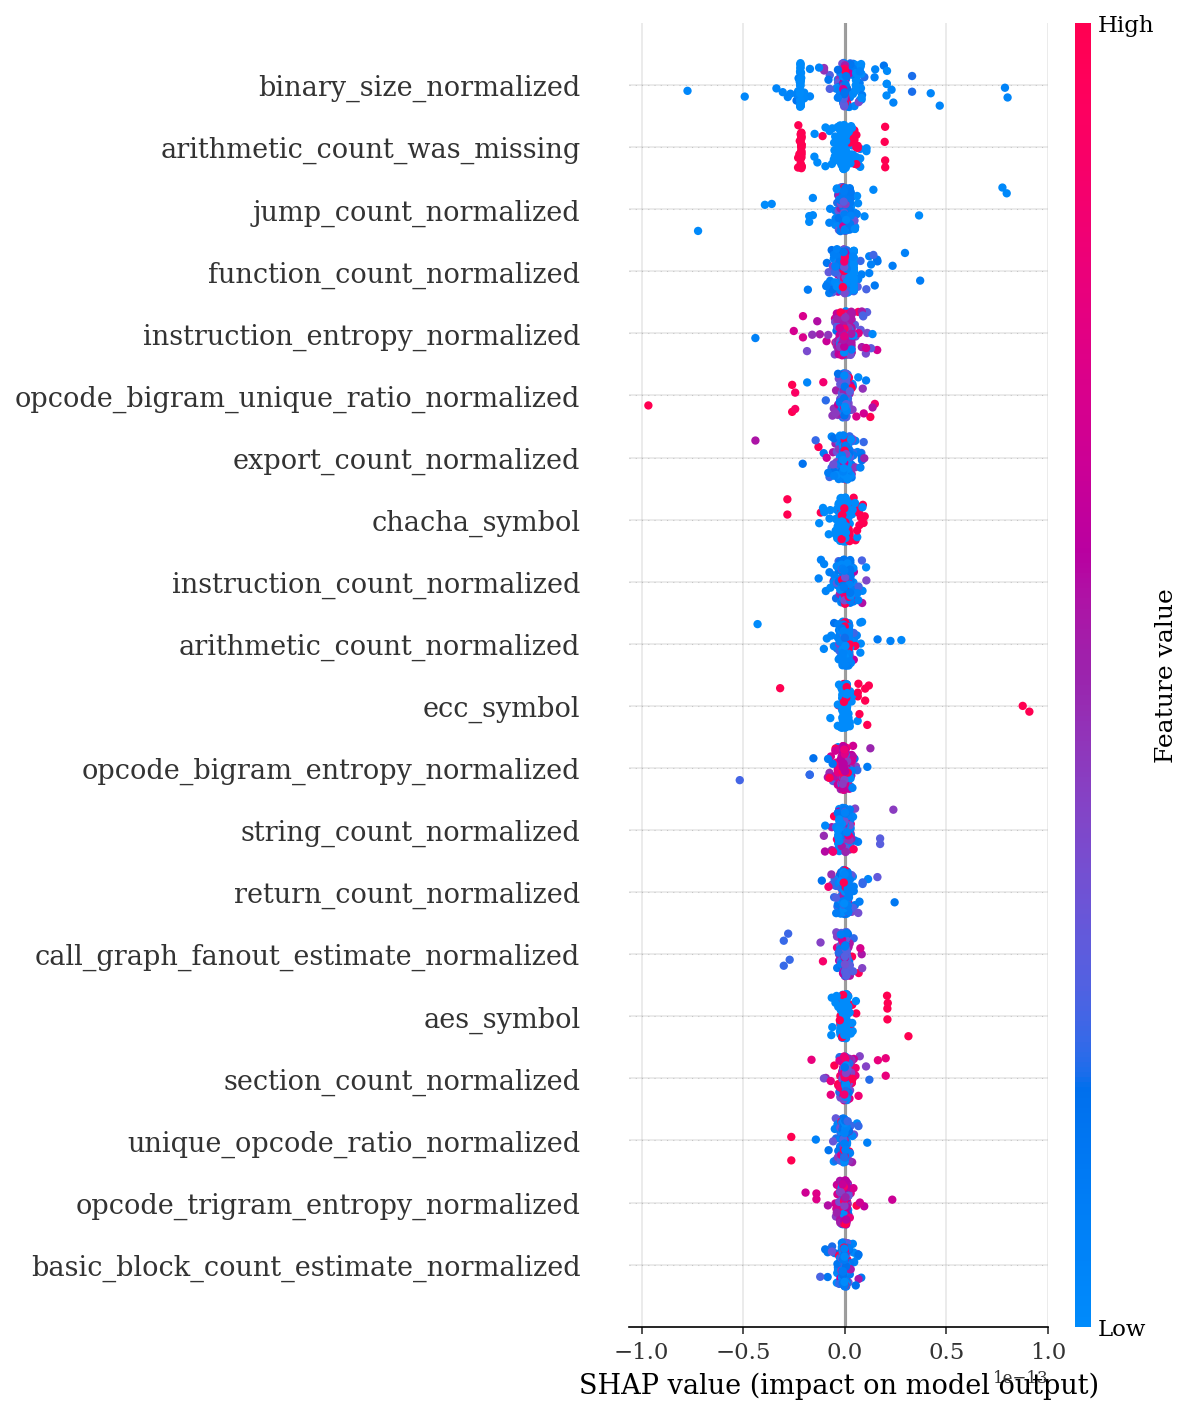

In [31]:
from IPython.display import Image, display as ipy_display

if shap_summary_path.exists():
    ipy_display(Image(filename=str(shap_summary_path)))
else:
    print(f"{shap_summary_path} not found.")

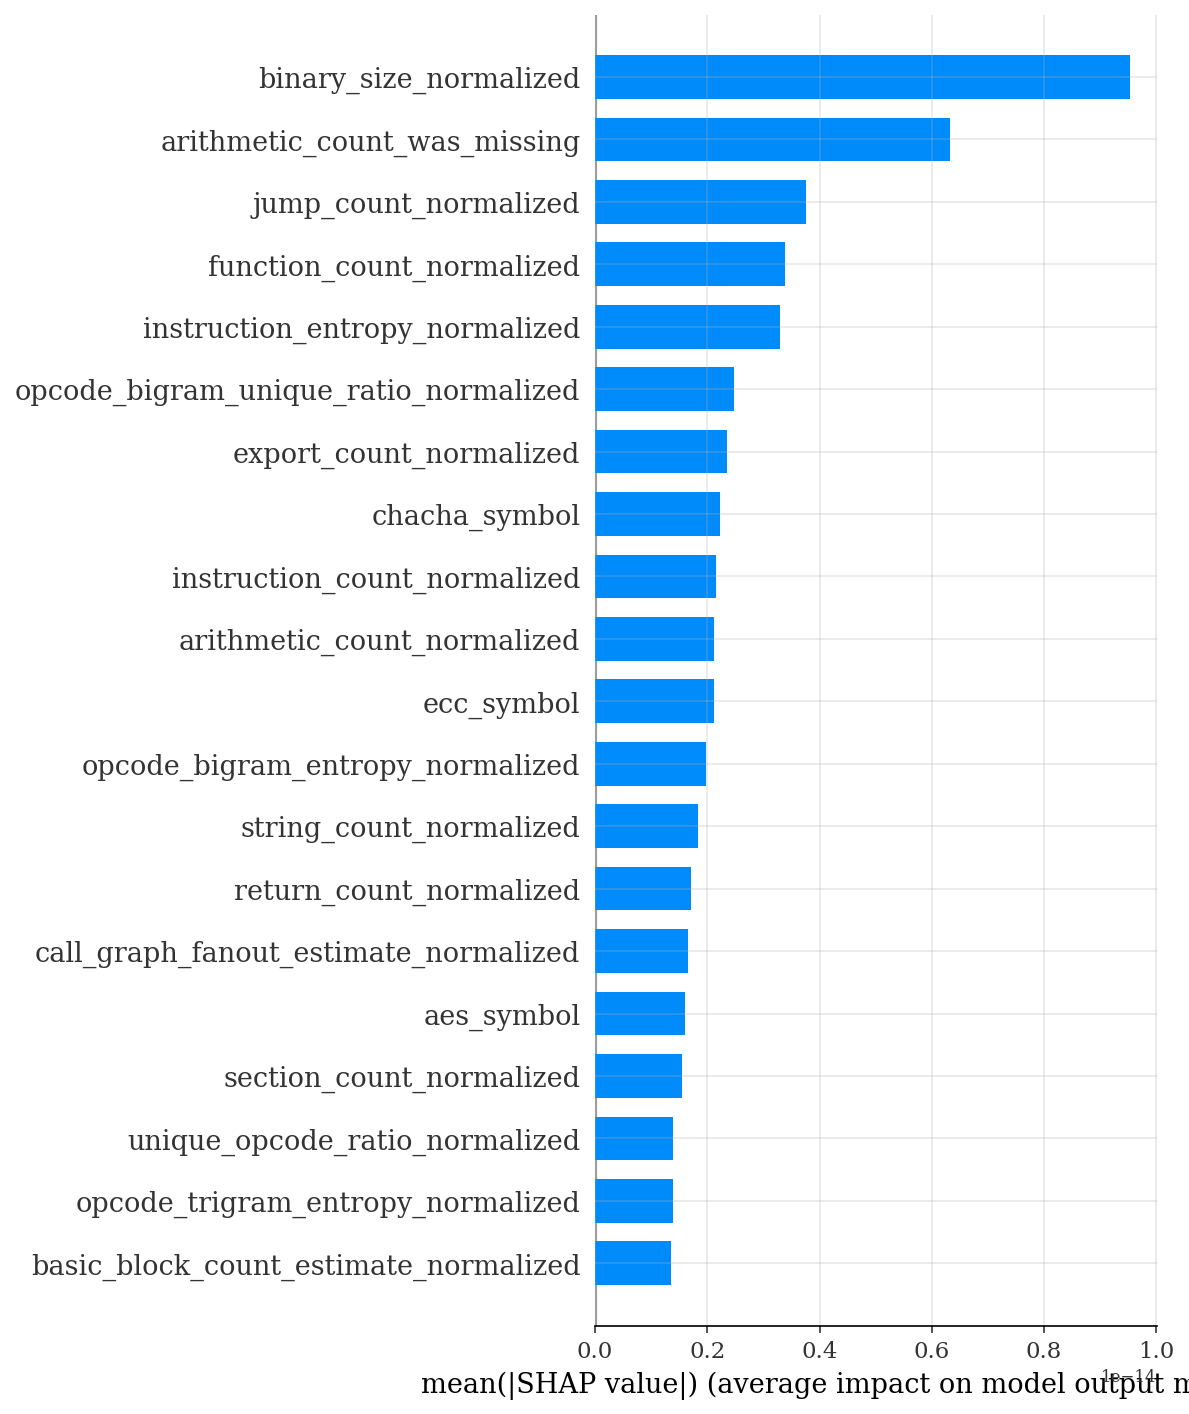

In [32]:
if shap_bar_path.exists():
    ipy_display(Image(filename=str(shap_bar_path)))
else:
    print(f"{shap_bar_path} not found.")

## 8. Runtime Inference via `ml.predict` (Real Pipeline, Not a Re-implementation)

Section 7 evaluated the model using the same in-process objects the training run
produced. This section instead goes through the *actual runtime inference path*
(`ml.predict.predict_single`) that a deployed system would use — feature-vector
validation/derivation included — for every test-set row, reconstructing each row's
`raw_features` dict from `test.csv` first. This is a genuine end-to-end integration
check: if `validate_and_prepare_features()` ever silently diverges from how
`train.py` built its training matrix, it will show up here as degraded metrics
relative to Section 7.

In [1]:
from ml.predict import (
    predict_single, get_model_bundle, reset_model_bundle_cache,
    PredictionValidationError, ModelLoadError, _NORMALIZED_SOURCE_KEYS,
)

reset_model_bundle_cache()  # force a fresh load in case Section 5/6 retrained the model
prediction_bundle = get_model_bundle()
print(f"predict.py loaded model_version={prediction_bundle.metadata.get('model_version')}, "
      f"{len(prediction_bundle.feature_columns)} feature columns.")

/home/manya_11/CryptoSage/venv/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator ExtraTreeClassifier from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/home/manya_11/CryptoSage/venv/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator ExtraTreesClassifier from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


predict.py loaded model_version=2.0, 28 feature columns.


/home/manya_11/CryptoSage/venv/lib/python3.12/site-packages/sklearn/base.py:525: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.8.0 when using version 1.9.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [1]:
def row_to_raw_features(row: pd.Series) -> dict:
    # Reconstruct an ml.predict-compatible raw feature dict from one test.csv row.
    #
    # Reverses ml/train.py's column naming: for every `<key>_normalized` selected
    # feature we recover the *raw* value from the corresponding un-normalized column
    # if it exists in test.csv, and pass booleans through as-is. This mirrors what
    # the real Firmware Analysis Engine's feature_vector.json would contain.
    raw = {}
    for column in prediction_bundle.feature_columns:
        if column in row.index and not column.endswith(("_normalized", "_encoded", "_was_missing")):
            raw[column] = row[column]
    for norm_col, source_key in _NORMALIZED_SOURCE_KEYS.items():
        if norm_col in prediction_bundle.feature_columns and source_key in row.index:
            raw[source_key] = row[source_key]
    for column in prediction_bundle.feature_columns:
        if column.endswith("_constant_count_normalized"):
            source_key = column[: -len("_normalized")]
            if source_key in row.index:
                raw[source_key] = row[source_key]
    return raw

test_predictions = []
prediction_failures = []
for idx, row in test_df.reset_index(drop=True).iterrows():
    raw_features = row_to_raw_features(row)
    binary_name = str(row.get("binary_name", f"test_row_{idx}"))
    try:
        result = predict_single(raw_features, binary_name=binary_name, explain=False)
        test_predictions.append({
            "binary_name": binary_name,
            "true_algorithm": str(row[TARGET_COLUMN]),
            "true_family": ALGORITHM_FAMILIES.get(str(row[TARGET_COLUMN]), "unknown"),
            "predicted_algorithm": result.algorithm,
            "predicted_family": result.algorithm_family,
            "confidence": result.confidence,
            "family_confidence": result.family_confidence,
            "prediction_time_ms": result.prediction_time_ms,
        })
    except (PredictionValidationError, RuntimeError) as exc:
        prediction_failures.append({"binary_name": binary_name, "error": str(exc)})

predictions_df = pd.DataFrame(test_predictions)
print(f"Predicted {len(predictions_df)}/{len(test_df)} test rows via the real ml.predict pipeline "
      f"({len(prediction_failures)} failures).")
if prediction_failures:
    print("First failure (for debugging):", prediction_failures[0])
predictions_df.head(10)

NameError: name 'pd' is not defined

In [ ]:
runtime_accuracy = (predictions_df["predicted_algorithm"] == predictions_df["true_algorithm"]).mean()
runtime_family_accuracy = (predictions_df["predicted_family"] == predictions_df["true_family"]).mean()
print(f"Runtime-path algorithm accuracy: {runtime_accuracy:.4f}  (Section 7 in-process accuracy: {metrics['accuracy']:.4f})")
print(f"Runtime-path family accuracy   : {runtime_family_accuracy:.4f}  (Section 7 in-process family accuracy: {metrics['family_accuracy']:.4f})")
if abs(runtime_accuracy - metrics['accuracy']) > 1e-6:
    print("\nNOTE: runtime-path and in-process accuracy differ. This usually means the row_to_raw_features() "
          "reconstruction above doesn't perfectly invert every derivation rule in validate_and_prepare_features() "
          "for a feature present in your specific dataset build — inspect the differing rows before reporting numbers.")
else:
    print("\nRuntime path matches in-process evaluation exactly — the inference pipeline is verified consistent.")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(IEEE_PAGE_WIDTH_IN, 3))
sns.histplot(predictions_df["confidence"], bins=20, ax=axes[0], color=sns.color_palette("colorblind")[4])
axes[0].set_title("Algorithm-prediction confidence distribution")
axes[0].set_xlabel("Confidence (%)")

correct = predictions_df["predicted_algorithm"] == predictions_df["true_algorithm"]
sns.boxplot(x=correct.map({True: "Correct", False: "Incorrect"}), y=predictions_df["confidence"], ax=axes[1],
            palette={"Correct": sns.color_palette("colorblind")[2], "Incorrect": sns.color_palette("colorblind")[3]})
axes[1].set_title("Confidence vs. prediction correctness")
axes[1].set_xlabel("")
axes[1].set_ylabel("Confidence (%)")

fig.tight_layout()
savefig_paper(fig, "fig10_confidence_calibration", "Prediction confidence distribution and its relationship to correctness — a simple calibration check.")
plt.show()

## 9. Risk Engine Evaluation (`ml.risk`)

`ml.risk.assess_risk()` is deterministic and config-driven (no ML), so "evaluating"
it means two different things, both covered below:

1. **Arithmetic verification** — confirm `risk_score == sum(category_scores)` for
   every assessment (a correctness check on the engine itself, not a machine-learned
   metric).
2. **Behavioural analysis on real test-set predictions** — feed every Section 8
   prediction's algorithm/family/confidence plus its real feature-vector row into
   `assess_risk()`, and look at the resulting score/level distribution. This is
   real, not synthetic: it's driven by your actual dataset and your actual trained
   model's predictions.

In [ ]:
from ml.risk import assess_risk, load_risk_config, RiskConfigError

try:
    risk_config = load_risk_config()
    print("risk_config.json loaded successfully.")
    print(f"Category weights: {risk_config['category_weights']}")
except RiskConfigError as exc:
    print(f"Could not load risk config: {exc}")
    print("This usually means `config.get_settings().RISK_CONFIG_PATH` isn't resolvable in this notebook's "
          "environment (e.g. missing environment variables your app's config.py expects). Set the required "
          "env vars the same way your backend does (e.g. via a .env file loaded before this notebook starts) "
          "and re-run this cell.")
    raise

In [ ]:
raw_feature_columns_for_risk = [c for c in test_df.columns
                                 if c not in (TARGET_COLUMN,) and c not in LEAKAGE_BASE_COLUMNS]

risk_assessments = []
risk_engine_failures = []
for _, pred_row in predictions_df.iterrows():
    matching_test_rows = test_df[test_df.get("binary_name", pd.Series(dtype=str)) == pred_row["binary_name"]]
    if matching_test_rows.empty:
        # Fall back to positional alignment if binary_name isn't a column in this dataset build.
        continue
    feature_vector = matching_test_rows.iloc[0][raw_feature_columns_for_risk].to_dict()
    try:
        assessment = assess_risk(
            firmware_id=hash(pred_row["binary_name"]) % 100000,
            algorithm=pred_row["predicted_algorithm"],
            algorithm_family=pred_row["predicted_family"],
            confidence=pred_row["confidence"],
            feature_vector=feature_vector,
        )
        risk_assessments.append(assessment)
    except (ValueError, RiskConfigError) as exc:
        risk_engine_failures.append({"binary_name": pred_row["binary_name"], "error": str(exc)})

print(f"Assessed risk for {len(risk_assessments)}/{len(predictions_df)} predictions "
      f"({len(risk_engine_failures)} failures).")
if risk_engine_failures:
    print("First failure:", risk_engine_failures[0])

In [ ]:
# --- Arithmetic verification: risk_score must equal the sum of category_scores ---
arithmetic_ok = all(
    abs(a.risk_score - sum(a.category_scores.values())) < 0.05  # allow float rounding only
    for a in risk_assessments
)
print(f"Arithmetic check (risk_score == sum(category_scores) for every assessment): "
      f"{'PASS' if arithmetic_ok else 'FAIL'}")

risk_df = pd.DataFrame([{
    "binary_name": pred_row["binary_name"],
    "algorithm": a.algorithm,
    "family": a.algorithm_family,
    "confidence": a.confidence,
    "risk_score": a.risk_score,
    "risk_level": a.risk_level,
    **{f"cat_{k}": v for k, v in a.category_scores.items()},
} for a, (_, pred_row) in zip(risk_assessments, predictions_df.iterrows())])

risk_df.head(10)

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(IEEE_PAGE_WIDTH_IN, 3.2))

sns.histplot(risk_df["risk_score"], bins=20, ax=axes[0], color=sns.color_palette("colorblind")[5])
axes[0].set_title("Risk score distribution")
axes[0].set_xlabel("Risk score (0-100)")

level_order = ["Safe", "Low", "Medium", "High", "Critical"]
level_counts = risk_df["risk_level"].value_counts().reindex(level_order).fillna(0)
level_colors = ["#2ca02c", "#8fbf3f", "#f5c542", "#e8743b", "#c0392b"]
axes[1].bar(level_counts.index, level_counts.values, color=level_colors)
axes[1].set_title("Risk level distribution")
axes[1].set_ylabel("Count")

fig.tight_layout()
savefig_paper(fig, "fig11_risk_score_distribution", "Distribution of computed risk scores and their mapped risk levels across the evaluated test-set predictions.")
plt.show()

In [ ]:
# Category-score stacked breakdown — shows which of the 4 weighted categories
# (algorithm_strength, deprecated_algorithm, binary_security, firmware_metadata)
# dominates the score for this dataset.
category_cols = [c for c in risk_df.columns if c.startswith("cat_")]
category_means = risk_df[category_cols].mean().sort_values(ascending=False)
category_means.index = [c.replace("cat_", "") for c in category_means.index]

fig, ax = plt.subplots(figsize=(IEEE_COL_WIDTH_IN, IEEE_COL_WIDTH_IN * 0.75))
ax.bar(category_means.index, category_means.values, color=sns.color_palette("colorblind")[:len(category_means)])
ax.set_ylabel("Mean contribution to risk score")
ax.set_title("Mean risk-score contribution by category")
ax.tick_params(axis="x", rotation=20)
fig.tight_layout()
savefig_paper(fig, "fig12_risk_category_contribution", "Mean contribution of each of the four weighted risk categories to the overall risk score.")
plt.show()

In [ ]:
# Which individual risk factors actually trigger, and how often — useful for a
# "risk-factor prevalence" table in the paper.
from collections import Counter

factor_trigger_counts = Counter()
for a in risk_assessments:
    for rf in a.risk_factors:
        if rf.contribution > 0:
            factor_trigger_counts[rf.factor] += 1

factor_trigger_df = pd.DataFrame(
    sorted(factor_trigger_counts.items(), key=lambda kv: kv[1], reverse=True),
    columns=["risk_factor", "trigger_count"],
)
factor_trigger_df["trigger_pct"] = (factor_trigger_df["trigger_count"] / len(risk_assessments) * 100).round(1)
factor_trigger_df

In [ ]:
if not factor_trigger_df.empty:
    fig, ax = plt.subplots(figsize=(IEEE_PAGE_WIDTH_IN, max(2.5, len(factor_trigger_df) * 0.28)))
    ax.barh(factor_trigger_df["risk_factor"][::-1], factor_trigger_df["trigger_pct"][::-1],
            color=sns.color_palette("colorblind")[6])
    ax.set_xlabel("% of assessed binaries triggering this factor")
    ax.set_title("Risk-factor trigger prevalence")
    fig.tight_layout()
    savefig_paper(fig, "fig13_risk_factor_prevalence", "Prevalence of each individual risk factor across the evaluated test-set predictions.")
    plt.show()
else:
    print("No risk factors triggered across the evaluated predictions.")

### 9a. Confidence-Dampening Sanity Check

`ml.risk._apply_confidence_adjustment()` should only ever pull the
`algorithm_strength` / `deprecated_algorithm` contributions **partway** toward
neutral for low-confidence predictions, never discard them. This cell verifies that
holds for every low-confidence assessment in your data — a genuine correctness test
of the engine, worth citing as a validation step in the paper's methodology.

In [ ]:
low_confidence_threshold = risk_config["confidence_adjustment"]["low_confidence_threshold"]
low_conf_mask = risk_df["confidence"] < low_confidence_threshold
print(f"{low_conf_mask.sum()}/{len(risk_df)} assessed predictions fall below the "
      f"{low_confidence_threshold}% confidence-adjustment threshold.")

if low_conf_mask.any():
    fig, ax = plt.subplots(figsize=(IEEE_COL_WIDTH_IN, IEEE_COL_WIDTH_IN * 0.75))
    sns.scatterplot(data=risk_df, x="confidence", y="risk_score", hue=low_conf_mask.map({True: "Below threshold", False: "At/above threshold"}),
                     palette={"Below threshold": "#c0392b", "At/above threshold": "#2ca02c"}, s=18, ax=ax)
    ax.axvline(low_confidence_threshold, color="gray", linestyle="--", linewidth=0.8)
    ax.set_xlabel("Prediction confidence (%)")
    ax.set_ylabel("Risk score")
    ax.set_title("Risk score vs. prediction confidence")
    ax.legend(title="", fontsize=7)
    fig.tight_layout()
    savefig_paper(fig, "fig14_confidence_dampening", "Risk score against prediction confidence, highlighting the confidence-adjustment threshold.")
    plt.show()
else:
    print("No low-confidence predictions in this run to visualize.")

## 10. Recommendation Engine Evaluation (`ml.recommend`)

Runs `generate_recommendations()` on every real risk assessment from Section 9 and
checks **rule coverage**: what fraction of triggered risk factors actually produced
a recommendation string, versus falling through with no configured rule. A coverage
gap here is a genuine finding worth reporting (it means `recommendation_rules.json`
is missing an entry for a factor `risk_config.json` can trigger).

In [ ]:
from ml.recommend import (
    generate_recommendations, load_recommendation_rules, RecommendationConfigError,
    _FACTOR_NAME_TO_RULE_KEY,
)

try:
    recommendation_rules = load_recommendation_rules()
    print("recommendation_rules.json loaded successfully.")
except RecommendationConfigError as exc:
    print(f"Could not load recommendation rules: {exc}")
    raise

recommendation_records = []
for a in risk_assessments:
    recs = generate_recommendations(a.risk_factors, algorithm=a.algorithm)
    recommendation_records.append({
        "algorithm": a.algorithm,
        "risk_level": a.risk_level,
        "num_triggered_factors": sum(1 for rf in a.risk_factors if rf.contribution > 0),
        "num_recommendations": len(recs),
        "recommendations": recs,
    })

recommendations_df = pd.DataFrame(recommendation_records)
recommendations_df.head(10)

In [ ]:
# Rule-coverage gap analysis: which triggered factor *names* have no entry in
# _FACTOR_NAME_TO_RULE_KEY, or map to a key with no configured recommendation text.
all_triggered_factor_names = Counter()
uncovered_factor_names = Counter()
for a in risk_assessments:
    for rf in a.risk_factors:
        if rf.contribution <= 0:
            continue
        all_triggered_factor_names[rf.factor] += 1
        if rf.category in ("binary_security", "firmware_metadata"):
            rule_key = _FACTOR_NAME_TO_RULE_KEY.get(rf.factor)
            section = {"binary_security": "binary_security_recommendations",
                       "firmware_metadata": "firmware_metadata_recommendations"}[rf.category]
            if rule_key is None or recommendation_rules.get(section, {}).get(rule_key) is None:
                uncovered_factor_names[rf.factor] += 1

coverage_pct = 100.0 * (1 - sum(uncovered_factor_names.values()) / max(1, sum(all_triggered_factor_names.values())))
print(f"Recommendation rule coverage across triggered factors: {coverage_pct:.1f}%")
if uncovered_factor_names:
    print("\nTriggered factors with NO configured recommendation (coverage gap):")
    for name, count in uncovered_factor_names.most_common():
        print(f"  - {name}: triggered {count} time(s), no rule configured")
else:
    print("Every triggered factor category we checked has a configured recommendation. "
          "(Note: 'algorithm_strength' is intentionally un-recommended by design — see "
          "ml/recommend.py's _recommendation_for_factor — to avoid duplicating the "
          "deprecated-algorithm message.)")

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(IEEE_PAGE_WIDTH_IN, 3))

sns.histplot(recommendations_df["num_recommendations"], bins=range(0, recommendations_df["num_recommendations"].max() + 2),
             ax=axes[0], color=sns.color_palette("colorblind")[0], discrete=True)
axes[0].set_title("Recommendations issued per assessment")
axes[0].set_xlabel("# recommendations")

sns.boxplot(data=recommendations_df, x="risk_level", y="num_recommendations",
            order=[lvl for lvl in level_order if lvl in recommendations_df["risk_level"].unique()],
            ax=axes[1], palette=dict(zip(level_order, level_colors)))
axes[1].set_title("Recommendation count by risk level")
axes[1].set_xlabel("")

fig.tight_layout()
savefig_paper(fig, "fig15_recommendation_summary", "Distribution of recommendation counts per assessment, and their relationship to the assigned risk level.")
plt.show()

In [ ]:
# Most frequently issued recommendations — good for a "top mitigations" table.
all_recs_flat = [rec for recs in recommendations_df["recommendations"] for rec in recs]
top_recommendations = pd.Series(Counter(all_recs_flat)).sort_values(ascending=False).head(10)
top_recommendations.to_frame("times_issued")

## 11. Session Summary & Figure Index

Run this last — it prints a manifest of every figure written to `paper_figures/`
(filenames + one-line captions you can adapt for your LaTeX `\caption{}`), plus a
final consolidated metrics block for quick copy-paste into a results section.

In [ ]:
print(f"{'Filename':40s} Caption")
print("-" * 100)
for name, caption in _saved_figures:
    print(f"{name + '.pdf':40s} {caption}")
print(f"\n{len(_saved_figures)} figure(s) written to: {FIGURES_DIR}")

In [ ]:
print("=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"Model                 : {model_metadata.get('winning_model')}")
print(f"Dataset version       : {model_metadata.get('dataset_version')}")
print(f"Train / test samples  : {model_metadata.get('training_sample_count')} / {model_metadata.get('test_sample_count')}")
print(f"Feature count         : {model_metadata.get('feature_count')}")
print("-" * 60)
print(f"Algorithm accuracy    : {metrics['accuracy']:.4f}")
print(f"Algorithm F1 (macro)  : {metrics['f1_macro']:.4f}")
print(f"Algorithm bal. acc.   : {metrics['balanced_accuracy']:.4f}")
print(f"Family accuracy       : {metrics['family_accuracy']:.4f}")
print(f"Family F1 (macro)     : {metrics['family_f1_macro']:.4f}")
if metrics.get("family_roc_auc_macro") is not None:
    print(f"Family ROC-AUC (macro): {metrics['family_roc_auc_macro']:.4f}")
print("-" * 60)
print(f"Risk engine arithmetic check : {'PASS' if arithmetic_ok else 'FAIL'}")
print(f"Recommendation rule coverage : {coverage_pct:.1f}%")
print(f"Mean risk score               : {risk_df['risk_score'].mean():.2f}")
print("=" * 60)